**교차분석**: 두 개 이상의 범주형 변수 간의 관계를 분석하는 방법 , 주로 범주형 데이터에서 변수 간의 빈도 분포를 비교하건, 변수 간의 상호 연관성을 파악할 때 사용

    1) 교차 분석의 목적
        - 변수 간 관계 탐색 : 두 범주형 변수 간의 상관성이나 연관성 파악
        - 빈도 분석 : 변수별로 특정 그룹에서 데이터가 얼마나 자주 나타는지 확인
        - 시각적 비교
    2) 교차분석의 결과는 교차표로 나타냄

In [2]:
import pandas as pd

path = 'C:/juehyeon/aice_test/materials/datasets/'
df = pd.read_csv(path + 'heart.csv')
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
## 교차표 생성
crosstab = pd.crosstab(df['sex'], df['output'])
print(crosstab)

output    0   1
sex            
0        24  72
1       114  93


crosstab 옵션
1. df['sex'] -> sex 열을 행으로 지정
2. df['output'] -> output 열을 열로 지정
3. normalize -> 기준 행, 열 지정

In [5]:
## 교차표 비율 계산 (행 기준)
row_percentage = pd.crosstab(df['sex'], df['output'], normalize = 'index') * 100
row_percentage

output,0,1
sex,,
0,25.000000,75.000000
1,55.072464,44.927536


[해석] 
1) 여성(sex = 0) 중 심장병 (output = 1)이 있는 경우의 비율 : 75.00%
2) 남성(sex = 1) 중 심장병 (output = 1)이 있는 경우의 비율 : 44.92%

In [6]:
## 교차표 비율 계산 (열 기준)
column_percentage = pd.crosstab(df['sex'], df['output'], normalize = 'columns') * 100
column_percentage

output,0,1
sex,,
0,17.391304,43.636364
1,82.608696,56.363636


[해석] 
1. 심장병이 있는 사람 중 여성의 비율 : 43.63 %
2. 심장병이 없는 사람 중 남성의 비율 : 82.60 %

In [10]:
## 교차표 비율 계산 (전체)
total_percentage = pd.crosstab(df['sex'], df['output'], normalize = True) * 100
print(total_percentage)

output          0          1
sex                         
0        7.920792  23.762376
1       37.623762  30.693069


[해석]
1. 전체 인구 중 여성이며 심장병이 있는 경우 : 23.76 %
2. 전체 인구 중 남성이며 심장병이 없는 경우 : 37.62 % 

In [11]:
## 교차표 비율 계산 (전체 + 합계 + 소숫점 자리 옵션 추가)

In [13]:
total_percentage_with_totals = pd.crosstab(df['sex'], df['output'], normalize = True, margins = True) * 100 
total_percentage_with_totals = total_percentage_with_totals.round(2)
total_percentage_with_totals

output,0,1,All
sex,,,
0,7.92,23.76,31.68
1,37.62,30.69,68.32
All,45.54,54.46,100.00


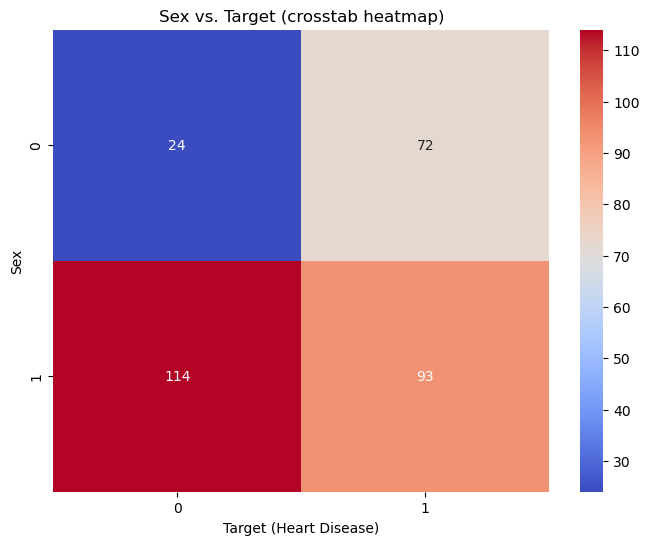

In [16]:
## 시각화하기
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 6))
sns.heatmap(crosstab, annot = True, fmt = "d", cmap = "coolwarm", cbar = True)
plt.title("Sex vs. Target (crosstab heatmap)")
plt.xlabel("Target (Heart Disease)")
plt.ylabel("Sex")
plt.show()